# Air-only validation

In [13]:
import sys, os
%matplotlib inline
from pathlib import Path

# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, load_elfe_batch
from elfe3d_gpr.outputs.postprocess import field_error, all_errors, error_stats
from elfe3d_gpr.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)


---
## Paths

In [14]:
MASTER_PATH = Path(r"..\elfe3D_GPR").resolve()

paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = r"elfe3d_gpr",
    use_wsl    = True,   # False if running from inside WSL
)

print('master   :', MASTER_PATH)
print('exec     :', paths.exec_path())


master   : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR
exec     : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


---
## 1 — Build and write inputs

`GPRSurvey.build()` assembles every sub-object, then `generate()` writes the `.poly` file and all FEM input files.

In [15]:
f    = 100e6
wave = 3e8 / f     # free-space wavelength = 3.0 m

survey = GPRSurvey.build(
    experiment_name = 'air_only',
    base_dir        = MASTER_PATH,

    # Domain
    x_e = [-wave/10, 1 + wave/10],
    y_e = [-wave/10,     wave/10],
    z_e = [-wave/10,     wave/10],

    # Materials — air only (whole-space)
    air_eps_r = 1.0,
    air_sigma = 1e-16,
    layer_thicknesses = [wave/10],  # thin dummy layer required by current implementation
    layer_eps_r       = [1.0],      # same as air
    layer_sigma       = [1e-16],
    layer_mu_r        = [1.0],
    layer_sigma_m     = [0.0],

    # Source
    ricker_central_f    = f,
    num_points_per_range = 1,
    antenna_position    = [0.0, 0.0, 0.025],
    source_type         = 6,
    current_direction   = 1,
    num_segments        = 1,
    s_f                 = 250,
    bh_f                = 1.0,
    box_present         = False,
    box_x               = [-1.0, 1.0],

    # Receivers  (inline = endfire/CO survey along x)
    num_receivers_inline  = 48,
    num_receivers_endfire = 0,
    num_receivers_oblique = 0,

    # Solver
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML
    num_pml_layers      = 1,
    pml_layer_thickness = wave/10,
    pml_type            = 'lin',
    pml_decay_type      = 1,

    least_samples_per_wavelength = 40,
)

survey.generate()
print('poly :', survey.io.poly_file)
print('inputs:', survey.io.input_dir)


odepths: [np.float64(0.01875), np.float64(0.01875)]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
[0.0]
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_air_only.poly
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\elfe3D_input.txt
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\source.txt
Written: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\regionparameters.txt
Input generation complete.
poly : F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_air_only.poly
inputs: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in


---
## 2 — Mesh with TetGen

In [16]:
# TetGen reads the .poly written by survey.generate()
run_tetgen(paths, survey.io.poly_file)


── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_air_only.poly

Opening GPR_model_air_only.poly.
Delaunizing vertices...
Delaunay seconds:  0.002339
Creating surface mesh ...
Surface mesh seconds:  0.001119
Constrained Delaunay...
Constrained Delaunay seconds:  0.001839
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000142
Refining mesh...
Refinement seconds:  1.64587
Optimizing mesh...
Optimization seconds:  0.077884

Writing GPR_model_air_only.1.node.
Writing GPR_model_air_only.1.ele.
Writing GPR_model_air_only.1.face.
Writing GPR_model_air_only.1.edge.
Writing GPR_model_air_only.1.vtk.
Writing GPR_model_air_only.1.neigh.

Output seconds:  1.35985
Total running seconds:  3.08911

Statistics:

  Input points: 226
  Input facets: 118
  Input segments: 329
  Input holes: 0
  Input regions: 36

  Mesh points: 76410
  Mesh tetrahedra

---
## 3 — Run solver

In [17]:
run_solver(paths, survey)


── elfe3d_gpr ────────────────────────────────────────
   wsl bash -c cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR && /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/elfe3d_gpr

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_air_only.                            
Your mesh has
       76410 Nodes
      454055 Elements
      538528 Edges (dof)
*************************************
Assembling connectivity arrays
Calcul

---
## 4 — Load results

In [18]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D  air_only',
    num_endfire = 48,   # matches num_receivers_inline above
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_air_only\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


---
## 5 — Analytical reference

In [19]:
# Half-space analytical quadrature reference (eps_r = 1 everywhere)
ANALYTICAL_DIR = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'

analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_air_100MHz_NR.csv'),
    label='analytical',
).endfire()


---
## 6 — Comparison plot

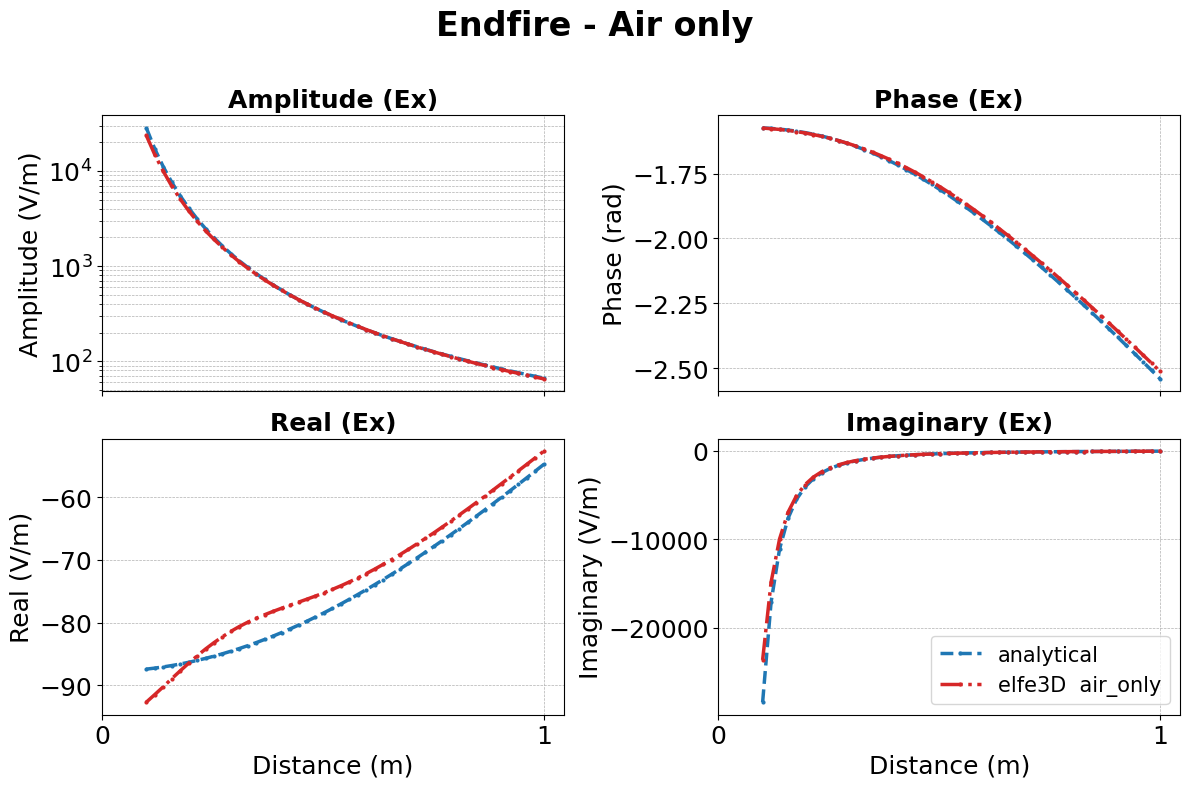

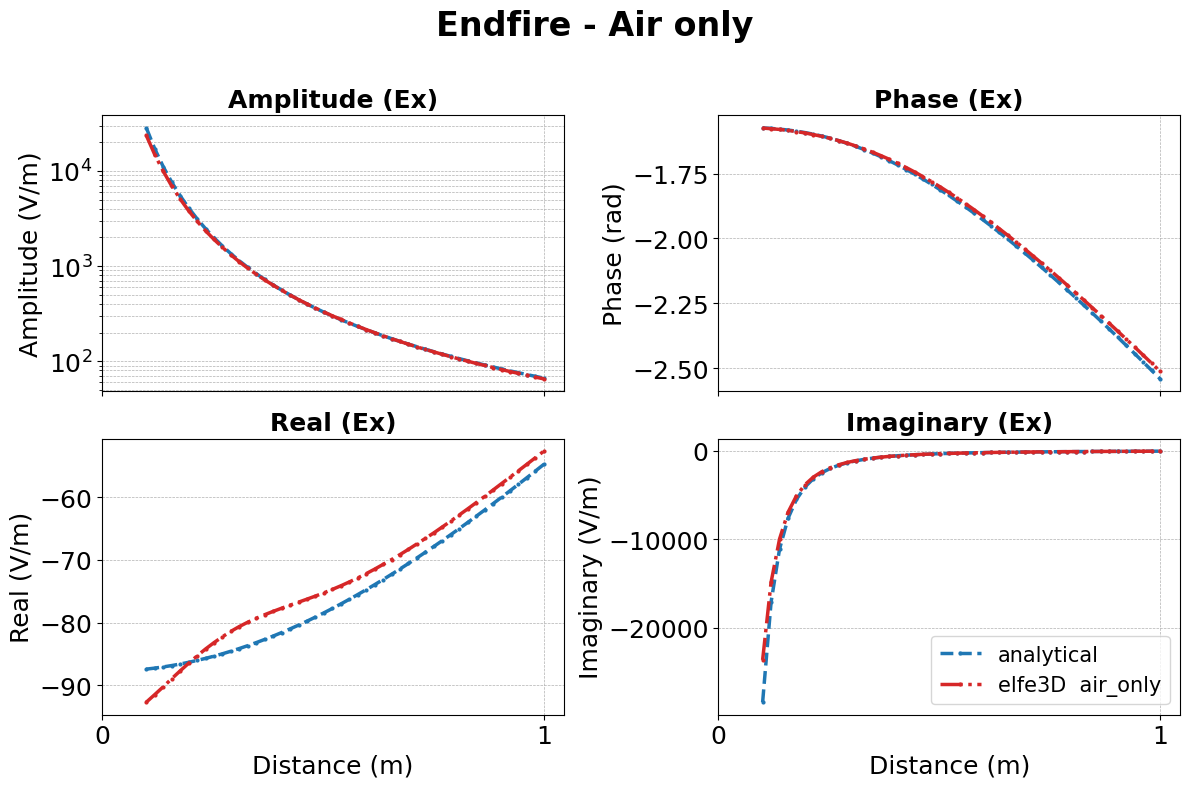

In [20]:
ReceiverLinePlot([analytical, ef],).plot(suptitle='Endfire - Air only')


## Error plot

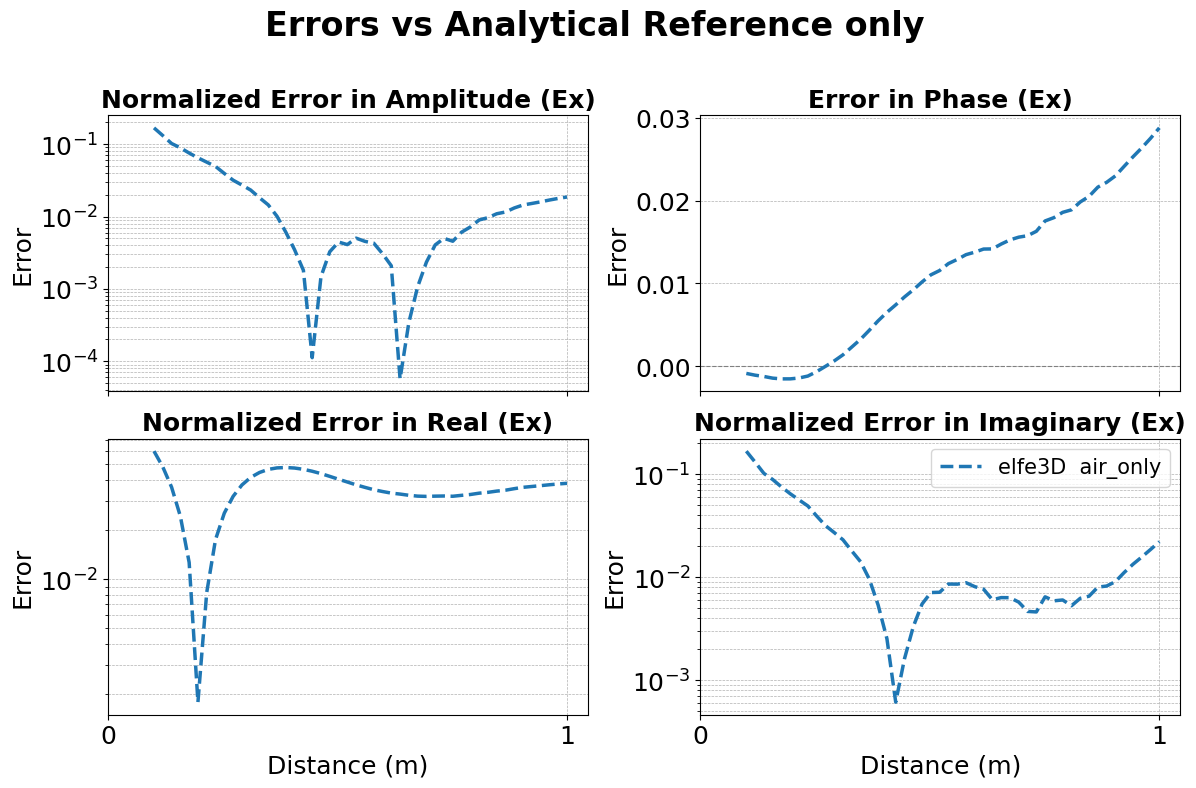

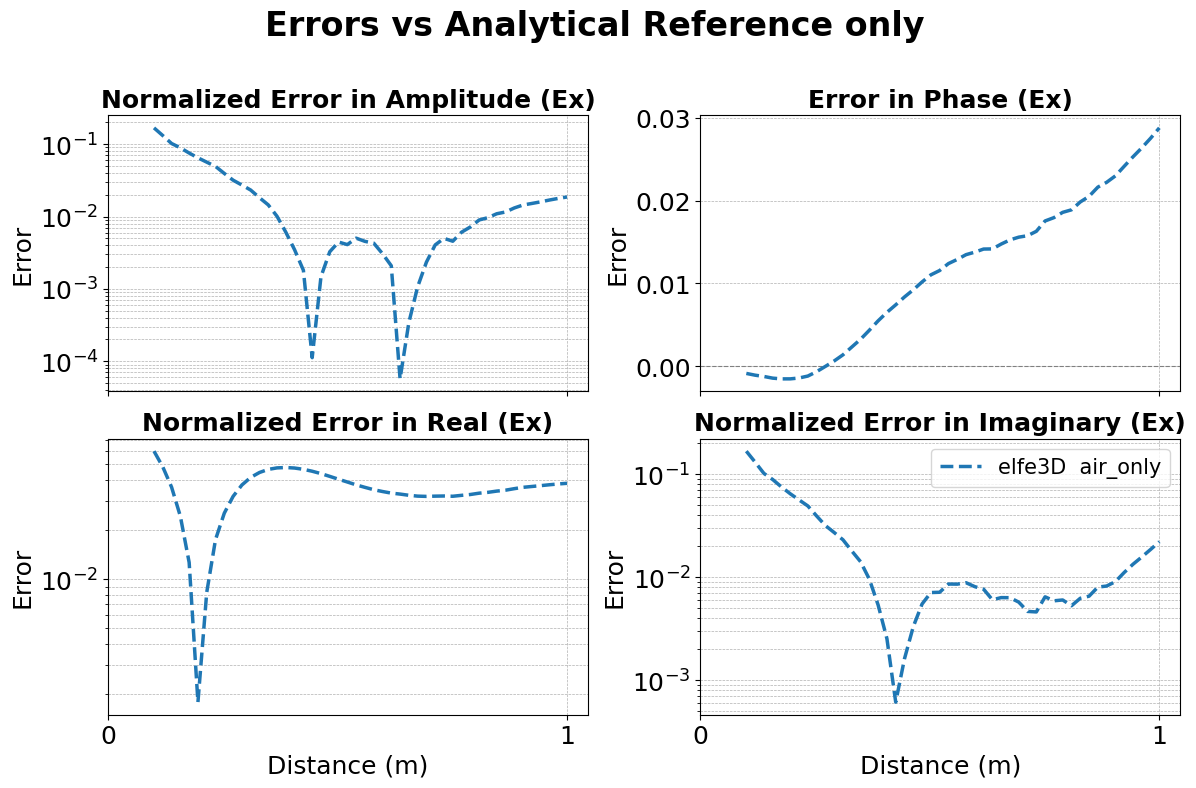

In [21]:
ReceiverLineErrorPlot([ef], reference=analytical).plot(suptitle='Errors vs Analytical Reference only')

## Combined (fields + errors)

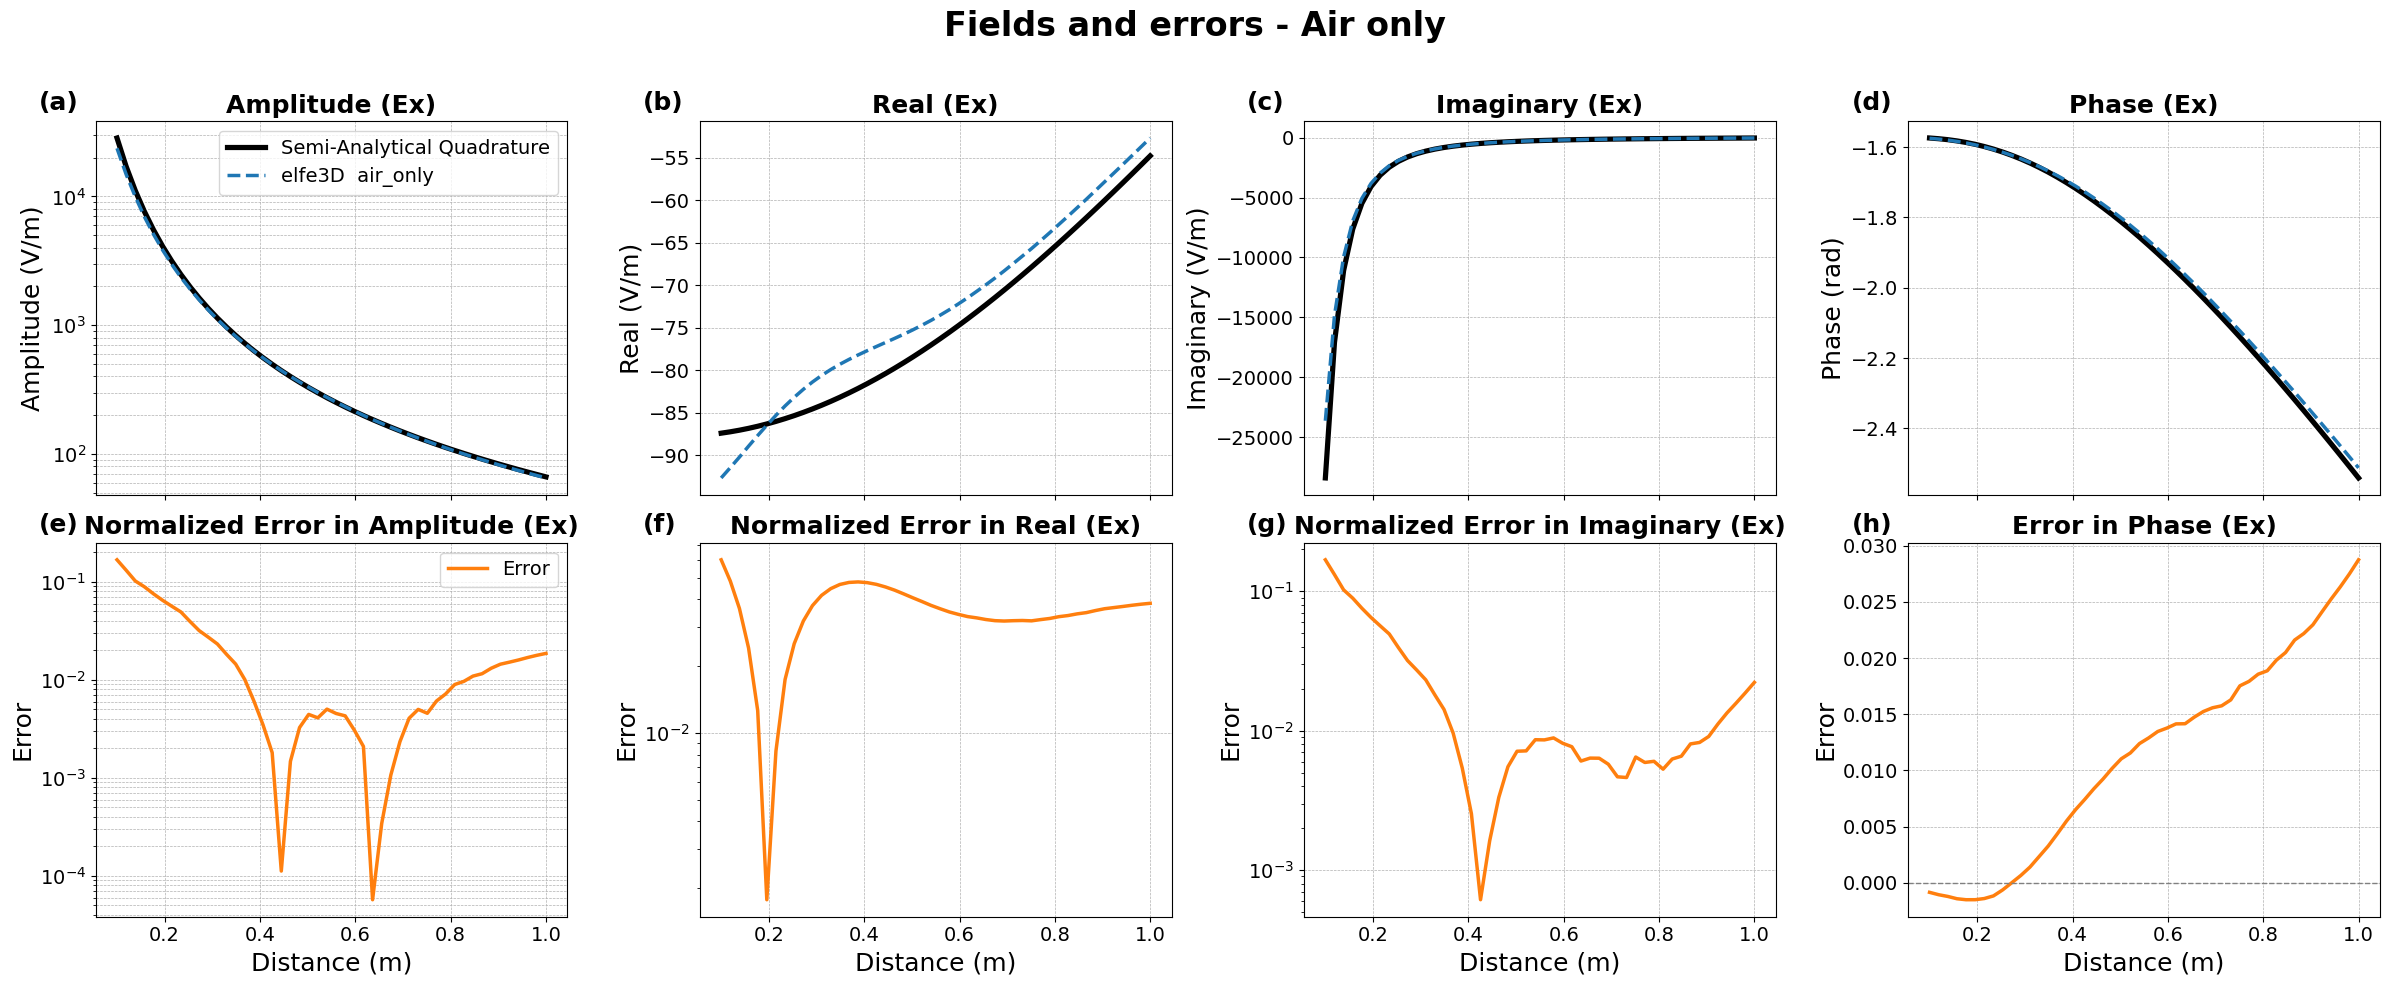

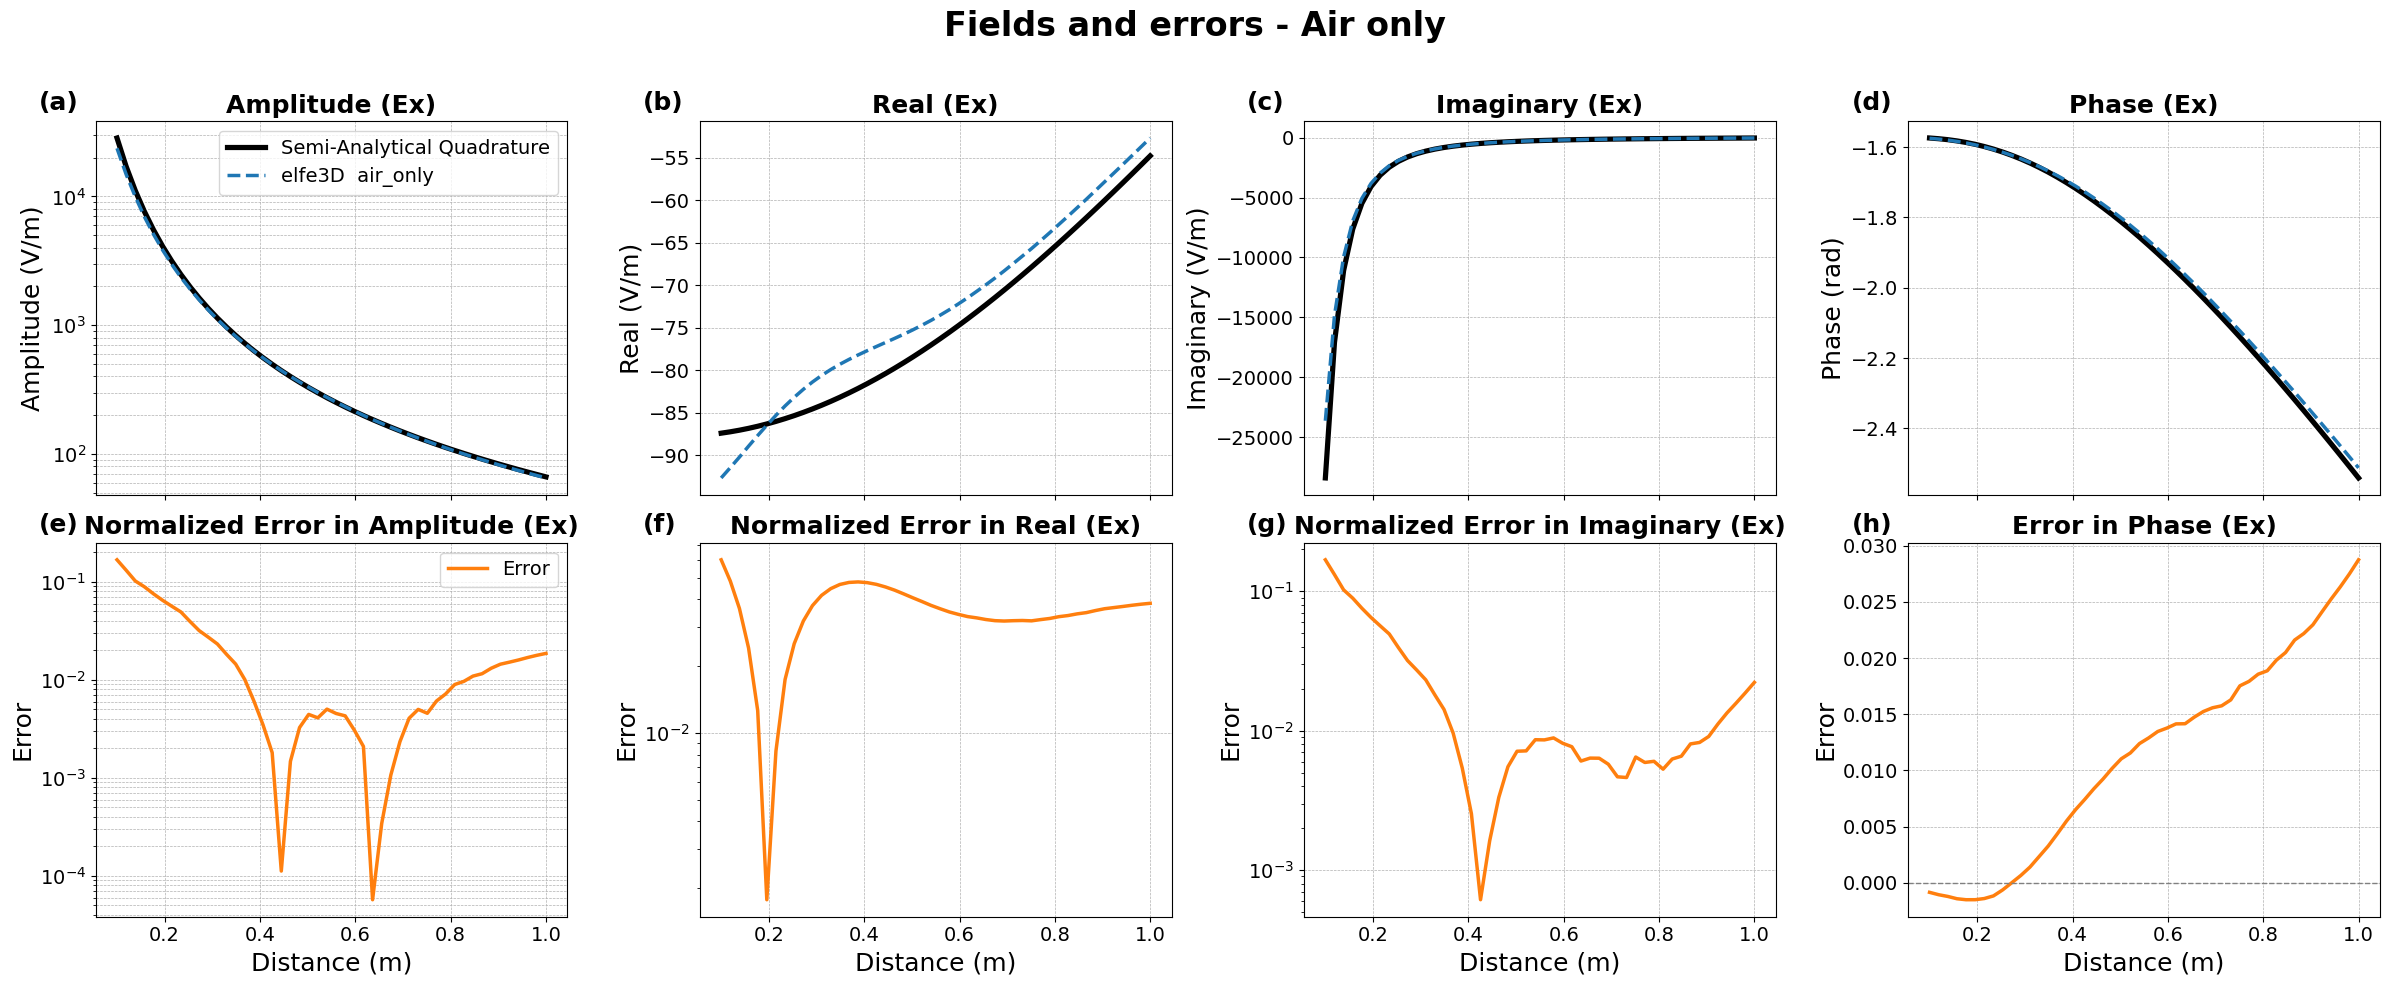

In [22]:
ReceiverLineCombined(ef, analytical).plot(suptitle='Fields and errors - Air only')


## Error histogram

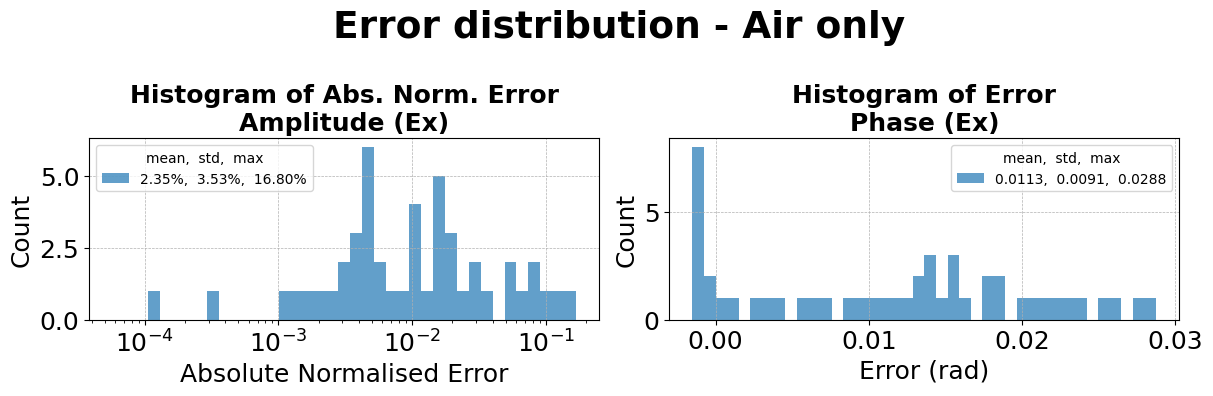

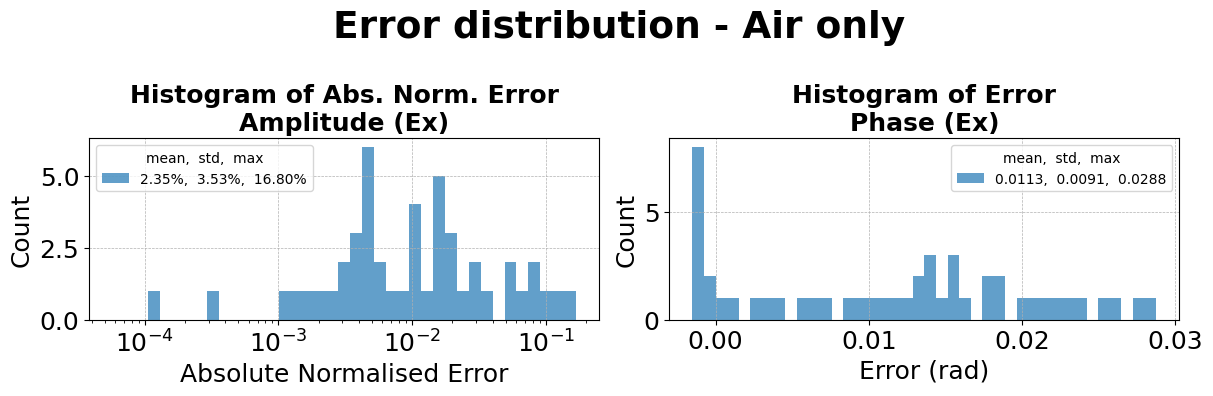

In [23]:
ErrorHistogramPlot([ef], reference=analytical).plot(suptitle='Error distribution - Air only')

## Printed error summary

In [24]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print(f'\n── {ef.label} ──')
for qi, name in enumerate(qty_names):
    err = field_error(analytical, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')



── elfe3D  air_only ──
  Amplitude   :  mean=2.352%  std=3.534%  max=16.802%
  Phase       :  mean=0.011rad  std=0.009rad  max=0.029rad
  Real        :  mean=3.542%  std=1.016%  max=6.020%
  Imaginary   :  mean=2.400%  std=3.500%  max=16.803%
